
# 8. Mask-only ablation tests for enriched high-gap words

This notebook builds a **simple masking-based ablation analysis** for your Reddit / WriteStreak posts with predicted valence and arousal.

It is designed for the setup you described:

- you already have a post-level file with **baseline predicted valence/arousal**
- you have a selected **enriched high-gap word list**
- you want to **mask those words**, rerun the model, and compute:
  - **Δvalence**
  - **Δarousal**
  - and absolute change magnitudes

This version is **mask only**. No replacement logic is included yet.


In [43]:

from pathlib import Path
import ast
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, ttest_rel, spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)



## Paths and configuration

Edit the settings below only if your file names or prediction-column names differ.


In [6]:
REPO_ROOT = Path.cwd()

# Try to use config if available; otherwise fall back to default folders.
processed_dir = REPO_ROOT / ".." / "data" / "processed"
tables_dir = REPO_ROOT / ".." / "reports" / "tables"
figures_dir = REPO_ROOT / ".." / "reports" / "figures"

try:
    import sys
    sys.path.insert(0, str(REPO_ROOT / ".." / "src"))
    from l2affect.utils.config import load_config, resolve  # type: ignore

    cfg = load_config(REPO_ROOT / ".." / "configs" / "config.yaml")
    processed_dir = resolve(cfg["paths"]["processed_dir"])
    tables_dir = resolve(cfg["paths"]["reports_tables_dir"])
    figures_dir = resolve(cfg["paths"]["reports_figures_dir"])
except Exception as e:
    print("Config not loaded (ok). Using default folders.")
    print("Reason:", e)

processed_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

output_dir = REPO_ROOT / "analysis_outputs"
data_path = processed_dir / "writestreak_full_with_predictions.csv"
word_path = processed_dir / "top30_highgap_words_mh_enriched_top5.csv"

ID_COL = "post_id"
TEXT_ID_COL = "text_id"
USER_COL = "user_id"
TEXT_COL = "text"
TOKENS_COL = "tokens"
N_TOKENS_COL = "n_tokens"

BASELINE_VALENCE_COL = "pred_valence_1_9"
BASELINE_AROUSAL_COL = "pred_arousal_1_9"

MASK_TOKEN = "[MASK]"
PREDICT_BATCH_SIZE = 64

# If True, only treated posts are rerun through the model.
RUN_ONLY_TREATED_POSTS = True

output_dir = REPO_ROOT / ".." / "data" / "analysis_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Prediction file:", data_path)
print("Enriched word file:", word_path)


Prediction file: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\writestreak_full_with_predictions.csv
Enriched word file: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\top30_highgap_words_mh_enriched_top5.csv


In [7]:

posts = pd.read_csv(data_path)
enriched_df = pd.read_csv(word_path)

print("Posts shape:", posts.shape)
print("Enriched word file shape:", enriched_df.shape)

display(posts.head(2))
display(enriched_df.head(10))


Posts shape: (9168, 43)
Enriched word file shape: (30, 8)


,post_id,post_fullname,author,user_id,created_utc,created_at,title,selftext,subreddit,permalink,score,num_comments,source_file,text,tokens,n_tokens,n_chars,post_index,days_since_first,user_post_count,high_gap_count,high_gap_density,high_gap_gapmag_mean,high_gap_gapmag_max,high_gap_valence_mean_signed,high_gap_arousal_mean_signed,swear_count,swear_density,swear_present,swear_unique_count,swear_types,high_gap_swear_count,mh_sim_max,mh_sim_mean_top3,mh_best_seed_idx,mh_best_seed,mh_best_seed_sim,mh_flag,text_id,pred_valence_raw,pred_arousal_raw,pred_valence_1_9,pred_arousal_1_9
0,j4p7n0,t3_j4p7n0,Stylelike,000a672e1864051f,1.601769e+09,2020-10-03 23:42:25+00:00,Streak 2: First aids,I think that learn first aids is indispensable...,WriteStreakEN,/r/WriteStreakEN/comments/j4p7n0/streak_2_firs...,1,4,202010.jsonl,Streak 2: First aids\n\nI think that learn fir...,"[""streak"", ""first"", ""aids"", ""i"", ""think"", ""tha...",65,350,2,1,4,1,0.015385,2.326908,2.326908,-1.61,1.68,0,0.0,0,0,[],0,0.141932,0.131127,12,I’ve had trouble concentrating on things like ...,0.141932,0,j4p7n0,-0.932517,0.294047,3.040777,4.359374
1,kk1866,t3_kk1866,Stylelike,000a672e1864051f,1.608912e+09,2020-12-25 16:01:26+00:00,Streak 1: Christmas and New Year.,"Firstly, I want to make it clear that I’m not ...",WriteStreakEN,/r/WriteStreakEN/comments/kk1866/streak_1_chri...,1,4,202012.jsonl,"Streak 1: Christmas and New Year.\n\nFirstly, ...","[""streak"", ""christmas"", ""and"", ""new"", ""year"", ...",115,639,4,84,4,1,0.008696,3.209190,3.209190,-0.50,3.17,0,0.0,0,0,[],0,0.354041,0.323948,1,Things I usually enjoy don’t feel enjoyable la...,0.354041,1,kk1866,2.007071,0.466640,6.832933,4.805484


,word,overall_token_count,overall_doc_count,overall_freq_per_10k_highgap_tokens,mh_token_count,mh_doc_count,mh_freq_per_10k_highgap_tokens,mh_enrichment_ratio
0,regain,9,9,4.548671,5.0,5.0,13.954786,3.067882
1,pace,66,61,33.356919,24.0,23.0,66.982975,2.008068
2,refresh,30,30,15.162236,10.0,10.0,27.909573,1.840729
3,assessment,15,14,7.581118,5.0,5.0,13.954786,1.840729
4,comfortable,254,236,128.373597,78.0,71.0,217.694669,1.695790
5,satisfaction,35,29,17.689275,10.0,10.0,27.909573,1.577768
6,breathe,53,48,26.786617,15.0,13.0,41.864359,1.562883
7,efficient,65,63,32.851511,18.0,17.0,50.237231,1.529221
8,normal,475,397,240.068735,129.0,108.0,360.033491,1.499710
9,extra,200,174,101.081573,54.0,43.0,150.711694,1.490991


In [8]:

required_post_cols = [
    ID_COL, TEXT_ID_COL, USER_COL, TEXT_COL, TOKENS_COL, N_TOKENS_COL,
    BASELINE_VALENCE_COL, BASELINE_AROUSAL_COL
]
missing_post_cols = [c for c in required_post_cols if c not in posts.columns]
if missing_post_cols:
    raise ValueError(f"Prediction file is missing required columns: {missing_post_cols}")

if "word" not in enriched_df.columns:
    raise ValueError("Enriched word file must contain a 'word' column.")



## Rebuild the selected-word treatment from the enriched word list


In [9]:

selected_words = (
    enriched_df["word"]
    .astype(str)
    .str.strip()
    .str.lower()
    .dropna()
    .unique()
)

selected_word_set = set(selected_words)

print("Number of selected enriched words:", len(selected_word_set))
print("Example words:", sorted(list(selected_word_set))[:15])


Number of selected enriched words: 30
Example words: ['assessment', 'assignment', 'begin', 'beginning', 'breathe', 'comfortable', 'decide', 'efficient', 'external', 'extra', 'fresh', 'good', 'graduate', 'great', 'grocery']


In [10]:

def parse_tokens(x):
    if isinstance(x, list):
        return [str(t).strip().lower() for t in x]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(t).strip().lower() for t in parsed]
        except Exception:
            pass
        return [tok.strip().lower() for tok in s.split()]
    return []

analysis_df = posts.copy()
analysis_df["tokens_list"] = analysis_df[TOKENS_COL].apply(parse_tokens)

analysis_df["selected_hits"] = analysis_df["tokens_list"].apply(
    lambda toks: [t for t in toks if t in selected_word_set]
)
analysis_df["selected_hit_count"] = analysis_df["selected_hits"].apply(len)
analysis_df["selected_hit_type_count"] = analysis_df["selected_hits"].apply(
    lambda xs: len(set(xs))
)
analysis_df["has_selected_high_gap_word"] = (
    analysis_df["selected_hit_count"] > 0
).astype(int)
analysis_df["selected_hit_prop"] = (
    analysis_df["selected_hit_count"] / analysis_df[N_TOKENS_COL].clip(lower=1)
)

sanity = pd.DataFrame({
    "metric": [
        "total_posts",
        "posts_with_selected_high_gap_word",
        "posts_without_selected_high_gap_word",
        "share_with_selected_high_gap_word",
        "total_selected_word_hits",
    ],
    "value": [
        len(analysis_df),
        int(analysis_df["has_selected_high_gap_word"].sum()),
        int((analysis_df["has_selected_high_gap_word"] == 0).sum()),
        float(analysis_df["has_selected_high_gap_word"].mean()),
        int(analysis_df["selected_hit_count"].sum()),
    ]
})

display(sanity)


,metric,value
0,total_posts,9168.000000
1,posts_with_selected_high_gap_word,6482.000000
2,posts_without_selected_high_gap_word,2686.000000
3,share_with_selected_high_gap_word,0.707024
4,total_selected_word_hits,10606.000000



## Build simple masked texts

Perturbation:

- find occurrences of the selected enriched words
- replace them with `MASK_TOKEN`
- keep the rest of the text unchanged

The masking itself is done on the **raw text** using a case-insensitive regex with word boundaries.  
Hit counts are still computed from the parsed token list.


In [16]:

escaped_words = sorted([re.escape(w) for w in selected_word_set], key=len, reverse=True)
word_pattern = re.compile(r"\b(" + "|".join(escaped_words) + r")\b", flags=re.IGNORECASE)

def mask_selected_words(text, pattern=word_pattern, mask_token=MASK_TOKEN):
    if pd.isna(text):
        return ""
    return pattern.sub(mask_token, str(text))

analysis_df["masked_text_simple"] = analysis_df[TEXT_COL].apply(mask_selected_words)
analysis_df["text_changed_by_mask"] = (
    analysis_df["masked_text_simple"] != analysis_df[TEXT_COL].astype(str)
).astype(int)

display(
    analysis_df.loc[
        analysis_df["has_selected_high_gap_word"] == 1,
        [ID_COL, TEXT_COL, "masked_text_simple", "selected_hits"]
    ].head(3)
)


,post_id,text,masked_text_simple,selected_hits
1,kk1866,"Streak 1: Christmas and New Year.\n\nFirstly, ...","Streak 1: Christmas and New Year.\n\nFirstly, ...",[special]
3,18sthvq,Streak 2: The start of a story (fiction). note...,Streak 2: The start of a story (fiction). note...,[fresh]
4,18tq0cp,Streak X\n\nI wish you a good weekend 😁,Streak X\n\nI wish you a [MASK] weekend 😁,[good]


In [17]:

changed_summary = pd.DataFrame({
    "metric": [
        "treated_posts",
        "treated_posts_with_changed_text",
        "untreated_posts_with_changed_text"
    ],
    "value": [
        int(analysis_df["has_selected_high_gap_word"].sum()),
        int(((analysis_df["has_selected_high_gap_word"] == 1) & (analysis_df["text_changed_by_mask"] == 1)).sum()),
        int(((analysis_df["has_selected_high_gap_word"] == 0) & (analysis_df["text_changed_by_mask"] == 1)).sum()),
    ]
})
display(changed_summary)


,metric,value
0,treated_posts,6482
1,treated_posts_with_changed_text,6478
2,untreated_posts_with_changed_text,0



## Prepare the ablation subset

Usually you only need to rerun the model on posts that actually contain at least one selected word.  
That is the default behavior here.


In [22]:

if RUN_ONLY_TREATED_POSTS:
    ablation_df = analysis_df.loc[analysis_df["has_selected_high_gap_word"] == 1].copy()
else:
    ablation_df = analysis_df.copy()

print("Rows to rerun through the model:", len(ablation_df))
display(
    ablation_df[
        [
            ID_COL, TEXT_ID_COL, USER_COL,
            BASELINE_VALENCE_COL, BASELINE_AROUSAL_COL,
            "selected_hit_count", "selected_hit_type_count", "selected_hit_prop"
        ]
    ].head()
)

masked_writestreak_full_path = processed_dir / "9-masked_data.csv"
print(ablation_df.shape)
ablation_df.to_csv(masked_writestreak_full_path, index=False)

print("Saved:", masked_writestreak_full_path)



Rows to rerun through the model: 6482


,post_id,text_id,user_id,pred_valence_1_9,pred_arousal_1_9,selected_hit_count,selected_hit_type_count,selected_hit_prop
1,kk1866,kk1866,000a672e1864051f,6.832933,4.805484,1,1,0.008696
3,18sthvq,18sthvq,002305cde36be93b,5.790307,8.743247,1,1,0.002513
4,18tq0cp,18tq0cp,002305cde36be93b,4.755822,6.276048,1,1,0.125000
5,18vcv2t,18vcv2t,002305cde36be93b,5.946425,4.145765,1,1,0.005917
7,18xqnzc,18xqnzc,002305cde36be93b,3.756989,6.613257,1,1,0.015873


(6482, 51)
Saved: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\9-masked_data.csv



## Plug in your prediction function

Edit the next cell **before running the notebook**.

Your function should take a list of texts and return either:

- a DataFrame with two columns for masked predictions, or
- something that can be converted into one

The notebook expects the masked predictions to end up in these columns:

- `masked_pred_valence_1_9`
- `masked_pred_arousal_1_9`

You can keep the output on a 1 to 9 scale if that is what your baseline predictions use.



## Run masked inference


In [ ]:

masked_pred_df_path = processed_dir / "writestreak_full_with_predictions_masked.csv"

masked_pred_df = pd.read_csv(masked_pred_df_path)

if len(masked_pred_df) != len(ablation_df):
    raise ValueError(
        f"Prediction output length {len(masked_pred_df)} does not match input length {len(ablation_df)}"
    )


display(ablation_df.head())


,post_id,post_fullname,author,user_id,created_utc,created_at,title,selftext,subreddit,permalink,score,num_comments,source_file,text,tokens,n_tokens,n_chars,post_index,days_since_first,user_post_count,high_gap_count,high_gap_density,high_gap_gapmag_mean,high_gap_gapmag_max,high_gap_valence_mean_signed,high_gap_arousal_mean_signed,swear_count,swear_density,swear_present,swear_unique_count,swear_types,high_gap_swear_count,mh_sim_max,mh_sim_mean_top3,mh_best_seed_idx,mh_best_seed,mh_best_seed_sim,mh_flag,text_id,pred_valence_raw,pred_arousal_raw,pred_valence_1_9,pred_arousal_1_9,tokens_list,selected_hits,selected_hit_count,selected_hit_type_count,has_selected_high_gap_word,selected_hit_prop,masked_text_simple,text_changed_by_mask,post_id,post_fullname,author,user_id,created_utc,created_at,title,selftext,subreddit,permalink,score,num_comments,source_file,text,tokens,n_tokens,n_chars,post_index,days_since_first,user_post_count,high_gap_count,high_gap_density,high_gap_gapmag_mean,high_gap_gapmag_max,high_gap_valence_mean_signed,high_gap_arousal_mean_signed,swear_count,swear_density,swear_present,swear_unique_count,swear_types,high_gap_swear_count,mh_sim_max,mh_sim_mean_top3,mh_best_seed_idx,mh_best_seed,mh_best_seed_sim,mh_flag,text_id,pred_valence_raw_x,pred_arousal_raw_x,pred_valence_1_9_x,pred_arousal_1_9_x,tokens_list,selected_hits,selected_hit_count,selected_hit_type_count,has_selected_high_gap_word,selected_hit_prop,masked_text_simple,text_changed_by_mask,pred_valence_raw_y,pred_arousal_raw_y,pred_valence_1_9_y,pred_arousal_1_9_y,delta_valence,delta_arousal,abs_delta_valence,abs_delta_arousal
0,kk1866,t3_kk1866,Stylelike,000a672e1864051f,1.608912e+09,2020-12-25 16:01:26+00:00,Streak 1: Christmas and New Year.,"Firstly, I want to make it clear that I’m not ...",WriteStreakEN,/r/WriteStreakEN/comments/kk1866/streak_1_chri...,1,4,202012.jsonl,"Streak 1: Christmas and New Year.\n\nFirstly, ...","[""streak"", ""christmas"", ""and"", ""new"", ""year"", ...",115,639,4,84,4,1,0.008696,3.209190,3.209190,-0.50,3.17,0,0.0,0,0,[],0,0.354041,0.323948,1,Things I usually enjoy don’t feel enjoyable la...,0.354041,1,kk1866,2.007071,0.466640,6.832933,4.805484,"[streak, christmas, and, new, year, firstly, i...",[special],1,1,1,0.008696,"Streak 1: Christmas and New Year.\n\nFirstly, ...",1,kk1866,t3_kk1866,Stylelike,000a672e1864051f,1.608912e+09,2020-12-25 16:01:26+00:00,Streak 1: Christmas and New Year.,"Firstly, I want to make it clear that I’m not ...",WriteStreakEN,/r/WriteStreakEN/comments/kk1866/streak_1_chri...,1,4,202012.jsonl,"Streak 1: Christmas and New Year.\n\nFirstly, ...","[""streak"", ""christmas"", ""and"", ""new"", ""year"", ...",115,639,4,84,4,1,0.008696,3.209190,3.209190,-0.50,3.17,0,0.0,0,0,[],0,0.354041,0.323948,1,Things I usually enjoy don’t feel enjoyable la...,0.354041,1,kk1866,2.007071,0.466640,6.832933,4.805484,"['streak', 'christmas', 'and', 'new', 'year', ...",['special'],1,1,1,0.008696,"Streak 1: Christmas and New Year.\n\nFirstly, ...",1,1.998828,0.430845,6.815926,4.751316,0.017007,0.054168,0.017007,0.054168
1,18sthvq,t3_18sthvq,MarianneGoesOnline,002305cde36be93b,1.703769e+09,2023-12-28 13:06:30+00:00,Streak 2: The start of a story (fiction). note...,It was a freezing winter day when I walked alo...,WriteStreakEN,/r/WriteStreakEN/comments/18sthvq/streak_2_the...,1,1,2026-03-15 - Extracted Reddit Data - Submissio...,Streak 2: The start of a story (fiction). note...,"[""streak"", ""the"", ""start"", ""of"", ""a"", ""story"",...",398,2038,2,0,18,2,0.005025,3.167656,3.266435,0.24,3.09,0,0.0,0,0,[],0,0.255394,0.247869,13,My mind feels foggy and it’s hard to focus.,0.255394,0,18sthvq,1.166258,3.145291,5.790307,8.743247,"[streak, the, start, of, a, story, fiction, no...",[fresh],1,1,1,0.002513,Streak 2: The start of a story (fiction). note...,1,18sthvq,t3_18sthvq,MarianneGoesOnline,002305cde36be93b,1.703769e+09,2023-12-28 13:06:30+00:00,Streak 2: The start of a story (fiction). note...,It was a freezing winter day when I wa


## Compute signed and absolute deltas


In [41]:

ablation_df["delta_valence"] = (
    ablation_df[BASELINE_VALENCE_COL] - ablation_df["pred_valence_1_9_y"]
)
ablation_df["delta_arousal"] = (
    ablation_df[BASELINE_AROUSAL_COL] - ablation_df["pred_arousal_1_9_y"]
)

ablation_df["abs_delta_valence"] = ablation_df["delta_valence"].abs()
ablation_df["abs_delta_arousal"] = ablation_df["delta_arousal"].abs()
ablation_df["delta_affect_shift_mag"] = np.sqrt(
    ablation_df["delta_valence"] ** 2 + ablation_df["delta_arousal"] ** 2
)

display(
    ablation_df[
        [
            ID_COL,
            "selected_hit_count",
            BASELINE_VALENCE_COL,
            BASELINE_AROUSAL_COL,
            "pred_valence_1_9_y",
            "pred_arousal_1_9_y",
            "delta_valence",
            "delta_arousal",
            "abs_delta_valence",
            "abs_delta_arousal",
            "delta_affect_shift_mag",
        ]
    ].head()
)


,post_id,post_id,selected_hit_count,selected_hit_count,pred_valence_1_9,pred_arousal_1_9,pred_valence_1_9_y,pred_arousal_1_9_y,delta_valence,delta_arousal,abs_delta_valence,abs_delta_arousal,delta_affect_shift_mag
0,kk1866,kk1866,1,1,6.832933,4.805484,6.815926,4.751316,0.017007,0.054168,0.017007,0.054168,0.056775
1,18sthvq,18sthvq,1,1,5.790307,8.743247,5.771897,8.740696,0.018410,0.002551,0.018410,0.002551,0.018586
2,18tq0cp,18tq0cp,1,1,4.755822,6.276048,4.675831,6.333640,0.079990,-0.057591,0.079990,0.057591,0.098566
3,18vcv2t,18vcv2t,1,1,5.946425,4.145765,5.957864,4.158699,-0.011439,-0.012934,0.011439,0.012934,0.017267
4,18xqnzc,18xqnzc,1,1,3.756989,6.613257,3.702392,6.460042,0.054598,0.153215,0.054598,0.153215,0.162652



## Basic summaries


In [45]:

from scipy.stats import ttest_1samp

summary_table = pd.DataFrame({
    "metric": [
        "n_posts_rerun",
        "mean_abs_delta_valence",
        "median_abs_delta_valence",
        "mean_abs_delta_arousal",
        "median_abs_delta_arousal",
        "mean_delta_affect_shift_mag",
        "median_delta_affect_shift_mag",
        "mean_delta_valence_signed",
        "median_delta_valence_signed",
        "mean_delta_arousal_signed",
        "median_delta_arousal_signed",
    ],
    "value": [
        int(len(ablation_df)),
        float(ablation_df["abs_delta_valence"].mean()),
        float(ablation_df["abs_delta_valence"].median()),
        float(ablation_df["abs_delta_arousal"].mean()),
        float(ablation_df["abs_delta_arousal"].median()),
        float(ablation_df["delta_affect_shift_mag"].mean()),
        float(ablation_df["delta_affect_shift_mag"].median()),
        float(ablation_df["delta_valence"].mean()),
        float(ablation_df["delta_valence"].median()),
        float(ablation_df["delta_arousal"].mean()),
        float(ablation_df["delta_arousal"].median()),
    ]
})

display(summary_table)

magnitude_test_rows = []
for col in ["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag"]:
    x = ablation_df[col].dropna().astype(float)
    if len(x) == 0:
        continue

    t_stat, t_p = ttest_1samp(x, popmean=0.0)
    magnitude_test_rows.append({
        "outcome": col,
        "n": int(len(x)),
        "mean": float(x.mean()),
        "median": float(x.median()),
        "t_stat_vs_0": float(t_stat),
        "t_p_vs_0": float(t_p),
    })

magnitude_tests = pd.DataFrame(magnitude_test_rows)
display(magnitude_tests)


,metric,value
0,n_posts_rerun,6482.000000
1,mean_abs_delta_valence,0.089854
2,median_abs_delta_valence,0.063622
3,mean_abs_delta_arousal,0.082337
4,median_abs_delta_arousal,0.059410
5,mean_delta_affect_shift_mag,0.135192
6,median_delta_affect_shift_mag,0.106899
7,mean_delta_valence_signed,-0.024938
8,median_delta_valence_signed,-0.017287
9,mean_delta_arousal_signed,-0.029613


,outcome,n,mean,median,t_stat_vs_0,t_p_vs_0
0,abs_delta_valence,6482,0.089854,0.063622,78.303837,0.0
1,abs_delta_arousal,6482,0.082337,0.059410,80.594791,0.0
2,delta_affect_shift_mag,6482,0.135192,0.106899,99.876545,0.0


In [47]:

paired_test_rows = []

for outcome, masked_col, delta_col in [
    (BASELINE_VALENCE_COL, "pred_valence_1_9_y", "delta_valence"),
    (BASELINE_AROUSAL_COL, "pred_arousal_1_9_y", "delta_arousal"),
]:
    x = ablation_df[outcome].astype(float).to_numpy()
    y = ablation_df[masked_col].astype(float).to_numpy()
    d = ablation_df[delta_col].astype(float).to_numpy()

    row = {
        "outcome": outcome,
        "n": len(d),
        "mean_delta": float(np.mean(d)),
        "median_delta": float(np.median(d)),
    }

    try:
        t_stat, t_p = ttest_rel(x, y, nan_policy="omit")
        row["paired_t_stat"] = float(t_stat)
        row["paired_t_p"] = float(t_p)
    except Exception:
        row["paired_t_stat"] = np.nan
        row["paired_t_p"] = np.nan

    try:
        w_stat, w_p = wilcoxon(x, y)
        row["wilcoxon_stat"] = float(w_stat)
        row["wilcoxon_p"] = float(w_p)
    except Exception:
        row["wilcoxon_stat"] = np.nan
        row["wilcoxon_p"] = np.nan

    paired_test_rows.append(row)

paired_tests = pd.DataFrame(paired_test_rows)
display(paired_tests)


,outcome,n,mean_delta,median_delta,paired_t_stat,paired_t_p,wilcoxon_stat,wilcoxon_p
0,pred_valence_1_9,6482,-0.024938,-0.017287,-15.879001,9.858700e-56,7962319.0,6.248014e-64
1,pred_arousal_1_9,6482,-0.029613,-0.031423,-21.182296,2.412502e-96,6459396.0,7.247689e-159



## Dose-style analyses

These are still post-level summaries, but they let you check whether posts with:

- more masked hits
- more unique masked types
- higher selected-word proportion

show larger prediction shifts.


In [50]:

ablation_df = ablation_df.loc[:, ~ablation_df.columns.duplicated()].copy()

dose_summary = (
    ablation_df
    .groupby("selected_hit_count")
    .agg(
        n_posts=(ID_COL, "count"),
        mean_abs_delta_valence=("abs_delta_valence", "mean"),
        median_abs_delta_valence=("abs_delta_valence", "median"),
        mean_abs_delta_arousal=("abs_delta_arousal", "mean"),
        median_abs_delta_arousal=("abs_delta_arousal", "median"),
        mean_delta_affect_shift_mag=("delta_affect_shift_mag", "mean"),
        median_delta_affect_shift_mag=("delta_affect_shift_mag", "median"),
        mean_signed_delta_valence=("delta_valence", "mean"),
        mean_signed_delta_arousal=("delta_arousal", "mean"),
    )
    .reset_index()
    .sort_values("selected_hit_count")
)

display(dose_summary.head(20))


,selected_hit_count,n_posts,mean_abs_delta_valence,median_abs_delta_valence,mean_abs_delta_arousal,median_abs_delta_arousal,mean_delta_affect_shift_mag,median_delta_affect_shift_mag,mean_signed_delta_valence,mean_signed_delta_arousal
0,1,4057,0.069011,0.052329,0.064232,0.051081,0.104113,0.088786,-0.017592,-0.028609
1,2,1487,0.104267,0.077496,0.094035,0.072218,0.155541,0.135353,-0.025982,-0.031045
2,3,553,0.142870,0.112758,0.124921,0.101946,0.212007,0.186933,-0.038084,-0.043415
3,4,207,0.167402,0.113312,0.141287,0.122868,0.246139,0.206567,-0.062457,-0.042655
4,5,91,0.174122,0.113913,0.173864,0.120005,0.275272,0.233300,-0.076470,-0.022098
5,6,45,0.199759,0.157165,0.184258,0.133012,0.300888,0.272016,-0.129292,0.063744
6,7,15,0.253650,0.150134,0.159174,0.093780,0.341572,0.288137,-0.138603,-0.098273
7,8,12,0.157637,0.122788,0.164160,0.120065,0.247328,0.236244,-0.119954,-0.013920
8,9,4,0.128321,0.075151,0.206760,0.226478,0.265188,0.228319,0.106582,0.047356
9,10,5,0.202897,0.228907,0.240787,0.246112,0.320665,0.336353,-0.019629,0.052572


In [51]:
corr_rows = []

for x_col in ["selected_hit_count", "selected_hit_type_count", "selected_hit_prop"]:
    for y_col in ["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag",
                  "delta_valence", "delta_arousal"]:
        sub = ablation_df[[x_col, y_col]].dropna()
        if len(sub) < 3:
            rho, p = np.nan, np.nan
        else:
            rho, p = spearmanr(sub[x_col], sub[y_col])

        corr_rows.append({
            "x": x_col,
            "y": y_col,
            "n": int(len(sub)),
            "spearman_rho": np.nan if pd.isna(rho) else float(rho),
            "p_value": np.nan if pd.isna(p) else float(p),
        })

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

,x,y,n,spearman_rho,p_value
0,selected_hit_count,abs_delta_valence,6482,0.258941,8.365321e-100
1,selected_hit_count,abs_delta_arousal,6482,0.252321,1.069210e-94
2,selected_hit_count,delta_affect_shift_mag,6482,0.361839,9.530696e-200
3,selected_hit_count,delta_valence,6482,-0.065405,1.361068e-07
4,selected_hit_count,delta_arousal,6482,-0.027017,2.961954e-02
5,selected_hit_type_count,abs_delta_valence,6482,0.140746,4.904039e-30
6,selected_hit_type_count,abs_delta_arousal,6482,0.135189,8.080553e-28
7,selected_hit_type_count,delta_affect_shift_mag,6482,0.202626,4.964089e-61
8,selected_hit_type_count,delta_valence,6482,-0.025013,4.403844e-02
9,selected_hit_type_count,delta_arousal,6482,-0.020923,9.210225e-02



## Plots


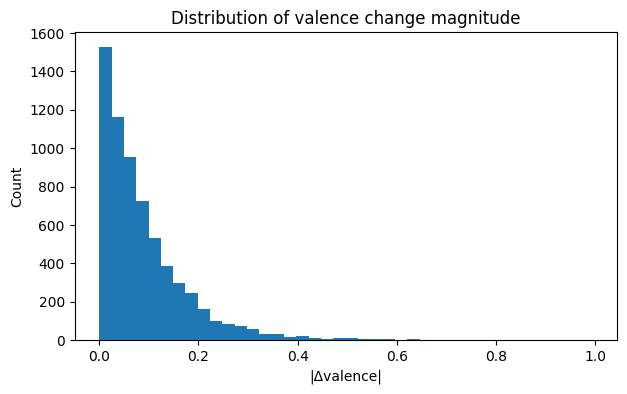

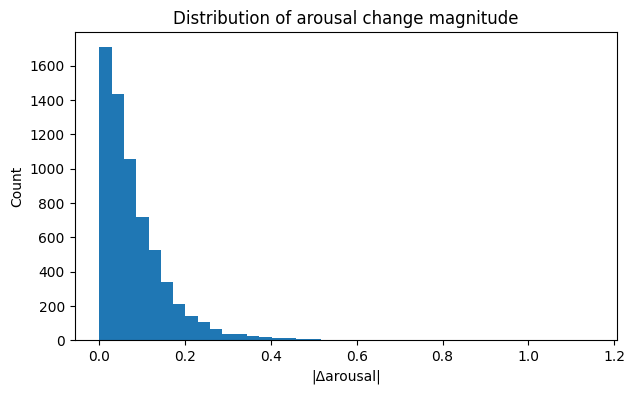

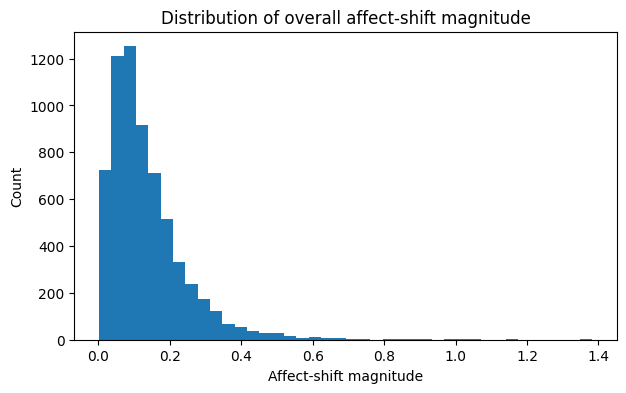

In [52]:
plt.figure(figsize=(7, 4))
plt.hist(ablation_df["abs_delta_valence"].dropna(), bins=40)
plt.xlabel("|Δvalence|")
plt.ylabel("Count")
plt.title("Distribution of valence change magnitude")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ablation_df["abs_delta_arousal"].dropna(), bins=40)
plt.xlabel("|Δarousal|")
plt.ylabel("Count")
plt.title("Distribution of arousal change magnitude")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ablation_df["delta_affect_shift_mag"].dropna(), bins=40)
plt.xlabel("Affect-shift magnitude")
plt.ylabel("Count")
plt.title("Distribution of overall affect-shift magnitude")
plt.show()

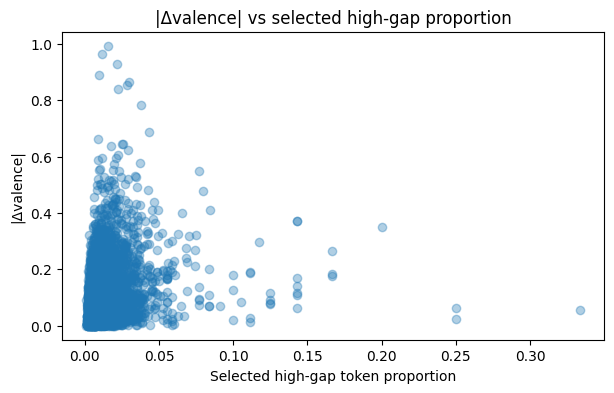

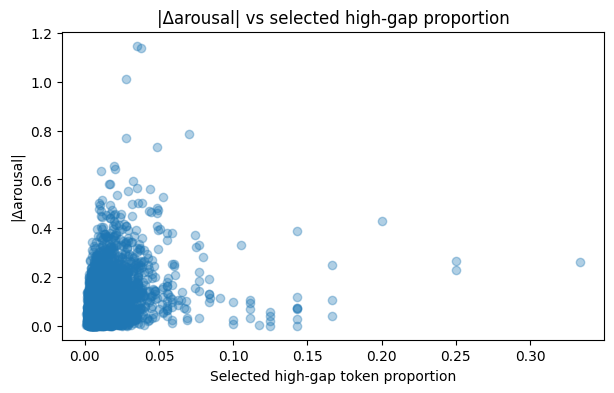

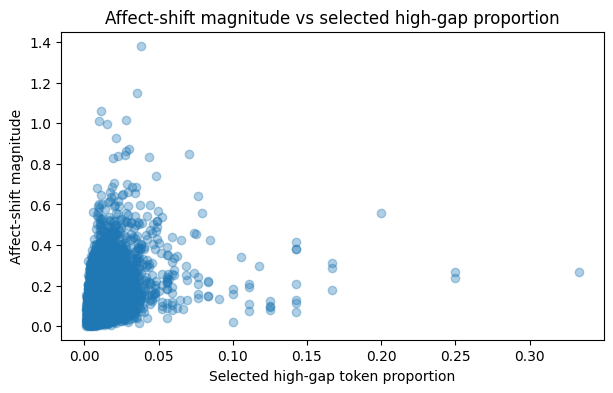

In [53]:
plt.figure(figsize=(7, 4))
plt.scatter(ablation_df["selected_hit_prop"], ablation_df["abs_delta_valence"], alpha=0.35)
plt.xlabel("Selected high-gap token proportion")
plt.ylabel("|Δvalence|")
plt.title("|Δvalence| vs selected high-gap proportion")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(ablation_df["selected_hit_prop"], ablation_df["abs_delta_arousal"], alpha=0.35)
plt.xlabel("Selected high-gap token proportion")
plt.ylabel("|Δarousal|")
plt.title("|Δarousal| vs selected high-gap proportion")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(ablation_df["selected_hit_prop"], ablation_df["delta_affect_shift_mag"], alpha=0.35)
plt.xlabel("Selected high-gap token proportion")
plt.ylabel("Affect-shift magnitude")
plt.title("Affect-shift magnitude vs selected high-gap proportion")
plt.show()


## Save outputs


In [55]:
ablation_results_path = tables_dir / "mask_ablation_results_magnitude.csv"
summary_path = tables_dir / "mask_ablation_summary_magnitude.json"
corr_path = tables_dir / "mask_ablation_correlations_magnitude.csv"
dose_path = tables_dir / "mask_ablation_dose_summary_magnitude.csv"
paired_tests_path = tables_dir / "mask_ablation_signed_direction_tests.csv"
magnitude_tests_path = tables_dir / "mask_ablation_magnitude_tests.csv"

ablation_df.to_csv(ablation_results_path, index=False)
corr_df.to_csv(corr_path, index=False)
dose_summary.to_csv(dose_path, index=False)
paired_tests.to_csv(paired_tests_path, index=False)
magnitude_tests.to_csv(magnitude_tests_path, index=False)

summary_payload = {
    "n_posts_rerun": int(len(ablation_df)),
    "mean_abs_delta_valence": float(ablation_df["abs_delta_valence"].mean()),
    "median_abs_delta_valence": float(ablation_df["abs_delta_valence"].median()),
    "mean_abs_delta_arousal": float(ablation_df["abs_delta_arousal"].mean()),
    "median_abs_delta_arousal": float(ablation_df["abs_delta_arousal"].median()),
    "mean_delta_affect_shift_mag": float(ablation_df["delta_affect_shift_mag"].mean()),
    "median_delta_affect_shift_mag": float(ablation_df["delta_affect_shift_mag"].median()),
    "mean_signed_delta_valence": float(ablation_df["delta_valence"].mean()),
    "mean_signed_delta_arousal": float(ablation_df["delta_arousal"].mean()),
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("Saved:")
print(" -", ablation_results_path.resolve())
print(" -", summary_path.resolve())
print(" -", corr_path.resolve())
print(" -", dose_path.resolve())
print(" -", paired_tests_path.resolve())
print(" -", magnitude_tests_path.resolve())

Saved:
 - C:\Users\hus44\Code\Directed-Reading-Project\reports\tables\mask_ablation_results_magnitude.csv
 - C:\Users\hus44\Code\Directed-Reading-Project\reports\tables\mask_ablation_summary_magnitude.json
 - C:\Users\hus44\Code\Directed-Reading-Project\reports\tables\mask_ablation_correlations_magnitude.csv
 - C:\Users\hus44\Code\Directed-Reading-Project\reports\tables\mask_ablation_dose_summary_magnitude.csv
 - C:\Users\hus44\Code\Directed-Reading-Project\reports\tables\mask_ablation_signed_direction_tests.csv
 - C:\Users\hus44\Code\Directed-Reading-Project\reports\tables\mask_ablation_magnitude_tests.csv


## How to interpret the main outputs

The most useful columns in `mask_ablation_results_magnitude.csv` are:

- `abs_delta_valence`
- `abs_delta_arousal`
- `delta_affect_shift_mag`

Interpretation:

- **larger `abs_delta_valence`** means masking the selected high-gap words changed the model's valence prediction more strongly
- **larger `abs_delta_arousal`** means masking changed the model's arousal prediction more strongly
- **larger `delta_affect_shift_mag`** means the overall point in 2D valence-arousal space moved farther after masking

Because your high-gap list contains words with **both positive and negative gap directions**, these magnitude outcomes should be treated as the **primary evidence** of influence.

The signed columns:

- `delta_valence`
- `delta_arousal`

are still useful for interpretation, but they should be considered **secondary**, since opposite-direction effects can cancel out when averaged.
